## Step 0: imports and seed

In [46]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

import time
import numpy as np
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import pandas as pd


np.random.seed(42)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1") 

## STEP 1: data


train data: Dataset({
    features: ['text'],
    num_rows: 36718
})
Number of texts is: 14616
Average len of texts: 719.8061713191023
*** Text number-0 is following:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 

*** Text number-1 is following:  The game began development in 2010 , carrying over a large portion of the work done on Valkyr

Text(0, 0.5, 'Частота')

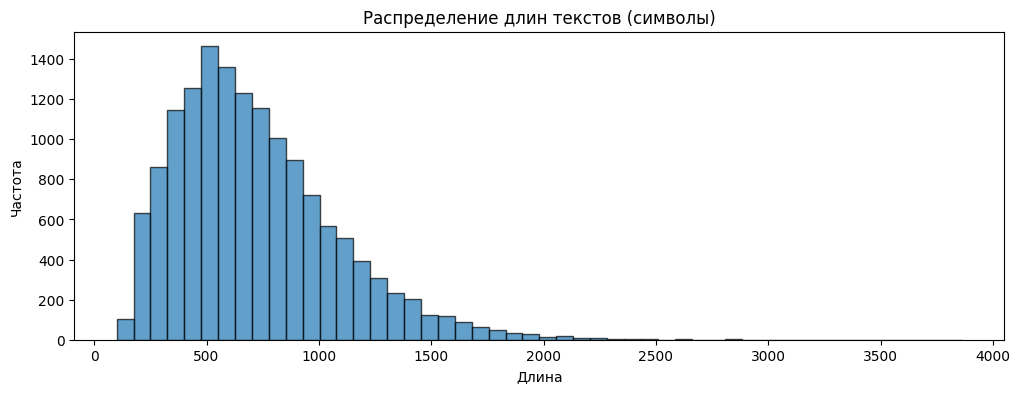

In [63]:
seq_len = 32
train_data = dataset['train']

print(f"train data: {train_data}")
# Берём исходные тексты без очистки
texts = [item['text'] for item in train_data]

# Фильтруем слишком короткие тексты по количеству слов (как и раньше)
texts = [line for line in dataset["train"]['text'] if len(line.split()) >= seq_len]

lengths_chars = [len(text) for text in texts]
print(f"Number of texts is: {len(texts)}")
print(f"Average len of texts: {np.mean(lengths_chars)}")
# Примеры текстов теперь будут с пунктуацией и регистром
for i in range(5):
    print(f"*** Text number-{i} is following: {texts[i]}")
    
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(lengths_chars, bins=50, edgecolor='black', alpha=0.7)
axes.set_title('Распределение длин текстов (символы)')
axes.set_xlabel('Длина')
axes.set_ylabel('Частота')

create vocab

In [ ]:
#Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
MASK_TOKEN = '<MASK>'

MIN_FREQ = 1

def build_vocab(texts, min_freq=MIN_FREQ):
    word_counts = Counter()
    for text in texts:
        words = text.split()
        word_counts.update(words)
    
    vocab_words = [word for word, count in word_counts.items() if count >= min_freq]
    
    special_tokens = [PAD_TOKEN, UNK_TOKEN, MASK_TOKEN]
    word2idx = {token: idx for idx, token in enumerate(special_tokens)}
    idx2word = {idx: token for token, idx in word2idx.items()}
    
    for word in vocab_words:
        if word not in word2idx:
            word2idx[word] = len(word2idx)
            idx2word[word2idx[word]] = word
    
    return word2idx, idx2word, word_counts

train_texts, val_texts = train_test_split(texts, test_size=0.05, random_state=42)

word2idx, idx2word, word_counts = build_vocab(train_texts, min_freq=2)

print(f"Размер словаря: {len(word2idx)}")
print(f"Специальные токены: {list(word2idx.keys())[:3]}")
print(f"Пример частот: {list(word_counts.most_common(10))}")

Размер словаря: 37336
Специальные токены: ['<PAD>', '<UNK>', '<MASK>']
Пример частот: [('the', 122467), ('of', 53059), ('and', 46969), ('in', 42003), ('to', 37147), ('a', 34227), ('was', 19793), ('on', 14205), ('as', 14095), ('s', 13551)]


Tokenezation function

In [ ]:
def tokenize_text(text, word2idx, max_len=512):
    words = text.split()
    indices = []
    for w in words:
        if w in word2idx:
            indices.append(word2idx[w])
        else:
            indices.append(word2idx[UNK_TOKEN])

    if len(indices) > max_len:
        indices = indices[:max_len]
    return indices

sample_text = texts[0]
sample_tokens = tokenize_text(sample_text, word2idx)
print("Example of tokenezation:", sample_tokens[:20])

Example of tokenezation: [24188, 301, 15063, 42, 9538, 15064, 1524, 42, 9141, 15063, 18, 3, 14984, 42, 579, 572, 26, 138, 15063, 15064]


create dataset and dataloader

In [50]:
class NextTokenDataset(Dataset):
    def __init__(self, texts, word2idx, seq_len=32):
        """
        texts: список строк (чистых текстов)
        word2idx: словарь слово -> индекс
        seq_len: итоговая длина последовательности (включая MASK)
        """
        self.samples = []
        pad_idx = word2idx[PAD_TOKEN]
        
        for text in texts:
            token_ids = tokenize_text(text, word2idx)  
            if len(token_ids) < seq_len+1:
                continue
            for i in range(0, len(token_ids) - seq_len):
                x = token_ids[i : i+seq_len]
                y = token_ids[i+1 : i+seq_len+1]
                self.samples.append((x,y))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)
 

Create Dataset and DataLoader

In [51]:
#min len of text in tokens
seq_len = 32
batch_size=64

print("Размер словаря:", len(word2idx))

train_dataset = NextTokenDataset(train_texts, word2idx, seq_len=seq_len)
val_dataset = NextTokenDataset(val_texts, word2idx, seq_len=seq_len)

print(f"Количество примеров в train: {len(train_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print(f"Форма батча x: {batch_x.shape}")   
print(f"Форма батча y: {batch_y.shape}")  

Размер словаря: 37336
Количество примеров в train: 1177419
Форма батча x: torch.Size([64, 32])
Форма батча y: torch.Size([64, 32])


## Этап 2. Реализация и обучение LSTM

creating class off model:

In [52]:
class NextTokenRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, rnn_type="LSTM", combine="concat"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        rnn_cls = {"RNN": nn.RNN, "GRU":nn.GRU, "LSTM":nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(
                           input_size=embed_dim,
                           hidden_size=hidden_dim,
                           num_layers=num_layers,
                           batch_first=True,
                           bidirectional=False
            )
        
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.rnn_type = rnn_type
    
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        logits = self.fc(out)
        return logits
    
    def generate(self, prompt_text, word2idx, idx2word, max_new_tokens=20, temperature=1.0, device='cpu'):
        self.eval()
        tokens = tokenize_text(prompt_text, word2idx)
        if len(tokens) == 0:
            return prompt_text + " " + UNK_TOKEN
        input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
        
        generated = tokens.copy()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                if input_ids.size(1) > seq_len:
                    input_ids = input_ids[:, -seq_len:]
                logits = self(input_ids)
                next_logits = logits[0, -1, :] / temperature
                probs = torch.softmax(next_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1).item()
                generated.append(next_token)
                input_ids = torch.cat([input_ids, torch.tensor([[next_token]], device=device)], dim=1)

        output_tokens = [idx2word.get(idx, UNK_TOKEN) for idx in generated]
        return ' '.join(output_tokens)
    
        

Help functions

In [53]:
def train_epoch(model, loader, optimizer, criterion, device, clip=1.0):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)  # (batch, seq_len, vocab_size)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    perplexity = np.exp(avg_loss)
    return avg_loss, perplexity

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, epochs, lr, device, clip=1.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    val_perplexities = []
    epoch_times = []   # новое
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device, clip)
        val_loss, val_ppl = eval_epoch(model, val_loader, criterion, device)
        end_time = time.time()
        
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_perplexities.append(val_ppl)
        
        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.2f} | Time: {epoch_duration:.2f}s")
    
    return train_losses, val_losses, val_perplexities, epoch_times

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

vocab_size = len(word2idx)
epochs = 5           
lr = 0.001


model_lstm = NextTokenRNN(vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, 
                          rnn_type='LSTM').to(device)

lstm_params = count_parameters(model_lstm)
print (f"LSTM parameters: {lstm_params}")

print("Training LSTM...")
lstm_train_loss, lstm_val_loss, lstm_val_ppl, lstm_epoch_time = train_model(
    model_lstm, train_loader, val_loader, epochs, lr, device, clip=1.0
)

Using device: cuda
LSTM parameters: 15295960
Training LSTM...
Epoch  1 | Train Loss: 5.4381 | Val Loss: 6.2195 | Val PPL: 502.46 | Time: 202.48s
Epoch  2 | Train Loss: 3.7805 | Val Loss: 7.0602 | Val PPL: 1164.65 | Time: 203.41s
Epoch  3 | Train Loss: 3.0751 | Val Loss: 7.8570 | Val PPL: 2583.69 | Time: 202.98s
Epoch  4 | Train Loss: 2.6726 | Val Loss: 8.5320 | Val PPL: 5074.57 | Time: 203.62s
Epoch  5 | Train Loss: 2.4256 | Val Loss: 9.0856 | Val PPL: 8826.88 | Time: 203.04s


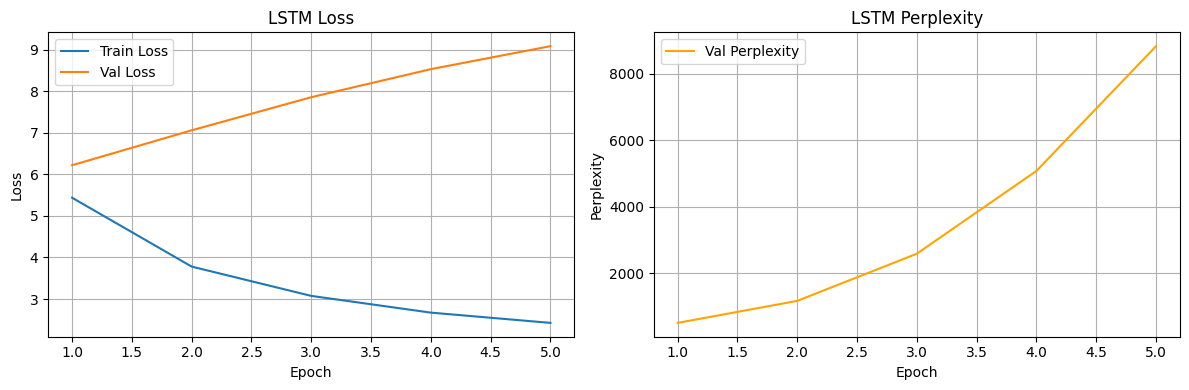

In [55]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), lstm_train_loss, label='Train Loss')
plt.plot(range(1, epochs+1), lstm_val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), lstm_val_ppl, label='Val Perplexity', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('LSTM Perplexity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Этап 3. Эксперимент: GRU vs LSTM

create model with GRU and train it

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

vocab_size = len(word2idx)
epochs = 5           
lr = 0.001


model_gru = NextTokenRNN(vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, 
                          rnn_type='GRU').to(device)

gru_params = count_parameters(model_gru)
print (f"GRU parameters: {gru_params}")

print("Training GRU...")
gru_train_loss, gru_val_loss, gru_val_ppl, gru_epoch_time = train_model(
    model_gru, train_loader, val_loader, epochs, lr, device, clip=1.0
)

Using device: cuda
GRU parameters: 15065560
Training GRU...
Epoch  1 | Train Loss: 4.7670 | Val Loss: 6.5528 | Val PPL: 701.18 | Time: 199.24s
Epoch  2 | Train Loss: 3.0808 | Val Loss: 7.3707 | Val PPL: 1588.73 | Time: 200.93s
Epoch  3 | Train Loss: 2.6928 | Val Loss: 7.8813 | Val PPL: 2647.21 | Time: 198.77s
Epoch  4 | Train Loss: 2.5053 | Val Loss: 8.2492 | Val PPL: 3824.38 | Time: 199.85s
Epoch  5 | Train Loss: 2.3898 | Val Loss: 8.5098 | Val PPL: 4963.39 | Time: 199.68s


compare of LSTM and GRU

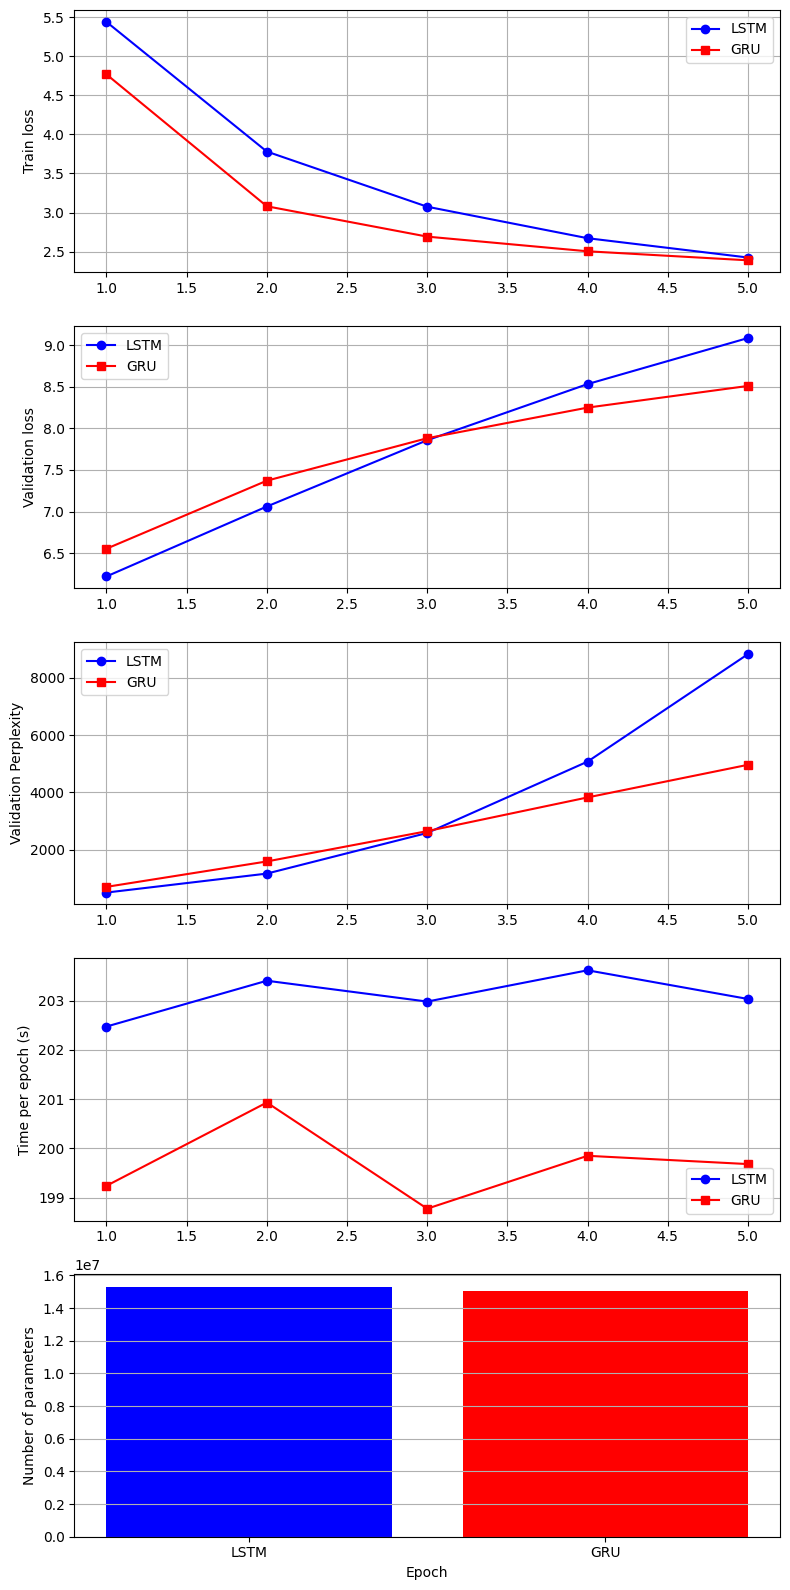

In [57]:
lstm_comp_list = [lstm_train_loss, lstm_val_loss, lstm_val_ppl, lstm_epoch_time]
gru_comp_list = [gru_train_loss, gru_val_loss, gru_val_ppl, gru_epoch_time]
name_comp_list = ["Train loss", "Validation loss", "Validation Perplexity", "Time per epoch (s)"]

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8,16))


epochs_range=range(1, epochs+1)

for i in range(len(lstm_comp_list)):
    axes[i].plot(epochs_range, lstm_comp_list[i], 'b-o', label='LSTM')
    axes[i].plot(epochs_range, gru_comp_list[i], 'r-s', label='GRU')
    axes[i].set_ylabel(name_comp_list[i])
    axes[i].legend()
    axes[i].grid(True)

axes[4].bar(['LSTM', 'GRU'], [lstm_params, gru_params], color=['blue', 'red'])
axes[4].set_ylabel("Number of parameters")
axes[4].grid(True, axis='y')

axes[-1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## Этап 4. Оценка distilgpt2

testing distilgpt2

In [ ]:
gpt2_model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(gpt2_model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(gpt2_model_name)

generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0
)

test_data = dataset['test']
test_texts_orig = [item['text'] for item in test_data]
test_texts = [t for t in test_texts_orig if len(t.split()) >= seq_len]
print(f"Number of test texts after cleaning: {len(test_texts)}")



Loading weights: 100%|██████████| 76/76 [00:00<00:00, 15161.34it/s]


Number of test texts after cleaning: 1760


calculate perplexity

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

def compute_perplexity(texts, model, tokenizer, batch_size=8, max_length=512):
    total_loss = 0.0
    total_tokens = 0
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(batch_texts, return_tensors='pt', 
                           truncation=True, max_length=max_length,
                           padding=True)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)

            loss = outputs.loss

            num_tokens = attention_mask.sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens
    
    avg_neg_log_lik = total_loss / total_tokens
    perplexity = np.exp(avg_neg_log_lik)
    return perplexity

perplexity = compute_perplexity(test_texts, model, tokenizer, batch_size=4)
print(f"Perplexity of distilgpt2 on WikiText-2 test set: {perplexity:.2f}")

100%|██████████| 440/440 [00:03<00:00, 116.56it/s]

Perplexity of distilgpt2 on WikiText-2 test set: 1607.59


Predictions exampel

In [60]:
test_texts_orig_filtered = [t for t in test_texts_orig if len(t.split()) >= 10]
print(f"Number of original test texts after filtering: {len(test_texts_orig_filtered)}")

print("\n--- Examples of text generation based on dataset texts ---")
sample_texts = random.sample(test_texts_orig_filtered, min(3, len(test_texts_orig_filtered)))

for i, text in enumerate(sample_texts, 1):
    words = text.split()
    prompt_len = min(15, len(words))
    prompt = ' '.join(words[:prompt_len])
    
    generated = generator(prompt, max_new_tokens=80, do_sample=True, temperature=0.7, max_length=None)
    full_generated = generated[0]['generated_text']
    
    if full_generated.startswith(prompt):
        continuation = full_generated[len(prompt):]
    else:
        continuation = full_generated
    
    print(f"Example {i}:")
    print(f"Prompt: {prompt}...")
    print(f"Generated continuation: {continuation}")
    print("-" * 80)

[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Number of original test texts after filtering: 2080

--- Examples of text generation based on dataset texts ---


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Example 1:
Prompt: Support for the IRA increased further after Bloody Sunday in January 1972 , when thirteen...
Generated continuation:  members of the IRA were shot in the face with a bullet.


In 1981, the IRA received an estimated 1,000 IRA members in Northern Ireland. Approximately 2,000 members were killed.
In 1981 the IRA received an estimated 3,500 members in Northern Ireland. Approximately 3,000 members were killed. The IRA was not the only organisation, but the only institution of terror in Ireland
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Example 2:
Prompt: = = = = Feud with Triple H and ending the Streak ( 2012 –...
Generated continuation:  2014 ) P = Feud with Triple H and ending the Streak ( 2012 – 2014 ) P = Feud with Triple H and ending the Streak ( 2012 – 2014 ) P = Feud with Triple H and ending the Streak ( 2012 – 2014 ) P = Feud with Triple H and ending the Streak ( 2012 – 2014 ) P = Feud with Triple H and ending the
--------------------------------------------------------------------------------
Example 3:
Prompt: = = = Severe Tropical Storm Melor ( Viring ) = = =...
Generated continuation:  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
--------------------------------------------------------------------------------


## Этап 5. Сравнение и выводы

In [61]:
try:
    lstm_test_ppl
except NameError:
    print("Вычисляем test perplexity для LSTM и GRU...")
    
    test_dataset = NextTokenDataset(test_texts, word2idx, seq_len=seq_len)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    criterion = torch.nn.CrossEntropyLoss()
    
    def compute_test_perplexity(model, loader, device):
        model.eval()
        total_loss = 0.0
        total_tokens = 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))

                num_tokens = x.size(0) * x.size(1)
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
        avg_loss = total_loss / total_tokens
        return np.exp(avg_loss)
    
    lstm_test_ppl = compute_test_perplexity(model_lstm, test_loader, device)
    gru_test_ppl = compute_test_perplexity(model_gru, test_loader, device)
    print(f"LSTM test perplexity: {lstm_test_ppl:.2f}")
    print(f"GRU test perplexity: {gru_test_ppl:.2f}")

gpt2_params = model.num_parameters()

avg_lstm_time = np.mean(lstm_epoch_time)
avg_gru_time = np.mean(gru_epoch_time)

data = {
    "Модель": ["LSTM", "GRU", "distilgpt2"],
    "Число параметров": [lstm_params, gru_params, gpt2_params],
    "Val Perplexity (последняя эпоха)": [lstm_val_ppl[-1], gru_val_ppl[-1], None],
    "Test Perplexity": [lstm_test_ppl, gru_test_ppl, perplexity],
    "Среднее время на эпоху (сек)": [avg_lstm_time, avg_gru_time, None]
}

df = pd.DataFrame(data)

print("\n" + "="*70)
print("Сводная таблица сравнения моделей")
print("="*70)
print(df.to_string(index=False, float_format="%.2f"))
print("="*70)

print("\nЛучшие val perplexity за обучение:")
print(f"LSTM min val PPL: {min(lstm_val_ppl):.2f} (эпоха {np.argmin(lstm_val_ppl)+1})")
print(f"GRU  min val PPL: {min(gru_val_ppl):.2f} (эпоха {np.argmin(gru_val_ppl)+1})")


Сводная таблица сравнения моделей
    Модель  Число параметров  Val Perplexity (последняя эпоха)  Test Perplexity  Среднее время на эпоху (сек)
      LSTM          15295960                           8826.88         15338.57                        203.10
       GRU          15065560                           4963.39          7276.62                        199.69
distilgpt2          81912576                               NaN          1607.59                           NaN

Лучшие val perplexity за обучение:
LSTM min val PPL: 502.46 (эпоха 1)
GRU  min val PPL: 701.18 (эпоха 1)


In [ ]:
num_examples = 5

indices = np.random.choice(len(test_texts_orig_filtered), size=num_examples, replace=False)

contexts = []
for idx in indices:
    text = test_texts_orig_filtered[idx]
    words = text.split()
    if len(words) >= 20:
        # Берём первые 15-20 слов в качестве промпта
        prompt_len = np.random.randint(15, 21)  # тоже детерминированно
        prompt = ' '.join(words[:prompt_len])
        contexts.append(prompt)

print("\n" + "="*100)
print("СРАВНЕНИЕ ГЕНЕРАЦИИ ТЕКСТА: LSTM vs GRU vs distilgpt2")
print("="*100)

for i, prompt in enumerate(contexts, 1):
    print(f"\n{'─'*100}")
    print(f"📌 КОНТЕКСТ {i}: {prompt}")
    print('─'*100)
    
    # 1. Генерация LSTM
    lstm_output = model_lstm.generate(
        prompt,  # LSTM обучен на очищенных текстах
        word2idx, idx2word,
        max_new_tokens=25,
        temperature=0.7,
        device=device
    )
    # Берём только сгенерированную часть (после промпта)
    lstm_continuation = lstm_output[len(prompt):]
    print(f"🔵 LSTM:     {prompt} {lstm_continuation}")
    
    # 2. Генерация GRU
    gru_output = model_gru.generate(
        prompt,
        word2idx, idx2word,
        max_new_tokens=25,
        temperature=0.7,
        device=device
    )
    gru_continuation = gru_output[len(prompt):]
    print(f"🟢 GRU:      {prompt} {gru_continuation}")
    
    # 3. Генерация distilgpt2
    try:
        # Для distilgpt2 используем оригинальный промпт (не очищенный)
        gpt_result = generator(
            prompt,
            max_new_tokens=25,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )
        gpt_full = gpt_result[0]['generated_text']
        if gpt_full.startswith(prompt):
            gpt_continuation = gpt_full[len(prompt):]
        else:
            gpt_continuation = gpt_full
        print(f"🟣 distilgpt2: {prompt} {gpt_continuation}")
    except Exception as e:
        print(f"🟣 distilgpt2: ошибка генерации — {e}")
    
    print()  # Пустая строка между примерами

print("="*100)
print("Примечание: LSTM и GRU генерируют на основе очищенного текста (нижний регистр, без пунктуации).")
print("distilgpt2 генерирует на основе исходного текста (сохраняя регистр и знаки).")
print("="*100)

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



СРАВНЕНИЕ ГЕНЕРАЦИИ ТЕКСТА: LSTM vs GRU vs distilgpt2

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 КОНТЕКСТ 1: Nero 's consolidation of power also included a slow usurping of authority from the Senate .
────────────────────────────────────────────────────────────────────────────────────────────────────
🔵 LSTM:     Nero 's consolidation of power also included a slow usurping of authority from the Senate .  of the british empire the final served consisted of a large beachhead between saint nazaire and <UNK> the ships of the commandos in the boiler
🟢 GRU:      Nero 's consolidation of power also included a slow usurping of authority from the Senate .  of an alien law at keeping the various legs of this particular period a standard of the historical migration of the colorado administration devastated new
🟣 distilgpt2: Nero 's consolidation of power also included a slow usurping of authority from the Senate . 


The Senate was not 

[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🟣 distilgpt2: During the Late Permian , increasing aridity and the diversification of reptiles contributed into a  widespread increase in the formation of new species of reptiles. It is believed that the increase in aridity and the diversification of


────────────────────────────────────────────────────────────────────────────────────────────────────
📌 КОНТЕКСТ 3: Kershaw was the Dodgers ' Opening Day starter for the second year in a row ,
────────────────────────────────────────────────────────────────────────────────────────────────────
🔵 LSTM:     Kershaw was the Dodgers ' Opening Day starter for the second year in a row ,  and went out of late september 2003 with his assistant <UNK> in 2002 eguchi had a great explanation at the <UNK> speech contrast soon after
🟢 GRU:      Kershaw was the Dodgers ' Opening Day starter for the second year in a row ,  as the shoulder i wanted to explain the poem and that his friend s involvement for the pursuit because in the series mask seems to
🟣 d

[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🟣 distilgpt2: Since the Song dynasty , critics have called Du Fu the " poet historian "  the poet of the South."






The Song dynasty has long been the most significant cultural event of


────────────────────────────────────────────────────────────────────────────────────────────────────
📌 КОНТЕКСТ 5: The three Type UB I boats of the Constantinople Flotilla seem to have patrolled primarily in the Black
────────────────────────────────────────────────────────────────────────────────────────────────────
🔵 LSTM:     The three Type UB I boats of the Constantinople Flotilla seem to have patrolled primarily in the Black ack plot and the arc goes out for wearing a baby garden on the side and performed a queen s child of the estate of the
🟢 GRU:      The three Type UB I boats of the Constantinople Flotilla seem to have patrolled primarily in the Black ack and waters of the north the <UNK> river has been a source of water to the crown where the location of the creeks is now
🟣 distilgpt2: The

# Сравнение качества (Perplexity)

1. distilgpt2 превосходит обе RNN-модели по тестовой перплексии более чем в 4–9 раз. Это ожидаемо, так как она предобучена на огромном датасете (800 ГБ данных).
2. GRU заметно лучше LSTM: тестовая перплексия ниже в 2 раза, валидационная – почти в 2 раза. GRU также имеет чуть меньше параметров (на ~300 тыс.) и обучается быстрее (~200 с против ~204 с за эпоху).
3. LSTM сильно переобучается, после первой эпохи вал. перплексия 515, а после этого резко растёт, что указывает на переобучение модели.

# Скорость и ресуры

1. LSTM и GRU требуют примерно одинакового времени обучения (~200 секунд на эпоху на GPU).
2. distilgpt2 имеет в 5 раз больше параметров, что увеличивает требования к памяти и времени инференса.

# Качество генерации (качественная оценка)
1. Генерации LSTM и GRU часто несвязны, содержат повторы, не соблюдают грамматику и теряют смысл через несколько слов.
2. distilgpt2 генерирует более осмысленные и грамматически правильные продолжения.

# Почему RNN-модели переобучаются?

1. Датасет WikiText-2 относительно невелик. RNN с 15 млн параметров легко переобучается. Для улучшения нужны:
2. Регуляризация (dropout, weight decay).
3. Early stopping.
4. Увеличение датасета .
5. Меньшие размерности.

# Рекомендации для продакт-менеджера

### Если главный критерий – качество генерации
Выбирать distilgpt2 (или более свежие модели).
Это обеспечит приемлемый уровень перплексии  и связные тексты.

### Если главный критерий – скорость и компактность
Использовать GRU – она компактнее LSTM и даёт лучшее качество при сравнимой скорости.
Для борьбы с переобучением обязательно применять dropout , уменьшите число слоёв и размерность.
